# **Machine learning: Reconnaissance de sorts (magiques)**

## 1. Introduction

### a) Rappels

Ce notebook fait suite au TP Perceptron dans lequel nous avions construit un petit réseau de neurones - appelé **perceptron** - pour effectuer de la reconnaissance de caractères.


<img src="https://github.com/PlantecJY/python-mic/raw/master/principe.png" alt="Drawing" width="300" align="center"/>


Nous avions suivi les étapes ci-dessous :
* **Structuration des données** pour l’apprentissage (un dictionnaire de chiffres écrits représentés par des tableaux 5*6, comme dans l'exemple ci-dessous

```
nb9b = [[1,1,1,1,1],
        [1,0,0,0,1],
        [1,0,0,0,1],
        [1,1,1,1,1],
        [0,0,0,0,1],
        [1,1,1,1,1]]
```
* **Création du réseau de neurones** : une couche d'entrée de dimension 300 et une couche de sortie de dimension 10 ; l'information passée à chaque neurone de sortie était simplement la combinaison linéaire des neurones reliés à cette sortie pondérée par le poids de chaque neurone ;
* **Test** du fonctionnement du réseau de neurones ;
* **Apprentissage**, c'est-dire-optimisation du poids de chaque neurone ;
* Utilisation du réseau de neurones pour une faire une **prédiction** : on fournit un chiffre sous forme de tableau et on demande au réseau de prédire ce chiffre.

### b) Objectif de ce TP

Dans ce TP, l'objectif est de comprendre toute la **chaîne d'apprentissage en Machine Learning** à travers le domaine de la **reconnaissance de gestes**, et plus particulièrement de sorts (magiques). Nous allons donc passer par les étapes suivantes:
  1) Acquisition des données brutes et construction d'un **dataset**
  2) **Split** données d'entraînement/ données de test
  3) **Pré-traitement** des données (génération de features)
  4) **Entraînement** d'un modèle léger (réseau de neurones)
  5) **Test** du modèle
  6) **Déploiement embarqué** sur une carte

 
### c) Etapes à suivre

1) **PARTIE 1**: Comprendre toute la chaîne d'apprentissage à travers un dataset déjà prêt
2) **PARTIE 2**: Déploiement embarqué sur carte du modèle
3) **PARTIE 3**: Compléter la base de donnée: ajoutez un nouveau geste et refaire la chaîne d'apprentissage jusqu'au déploiement.

## **PARTIE 1: Comprendre la chaîne d'apprentissage en machine learning**

## 1. Construction d'un dataset

Pour cette première étape, nous allons télécharger une base de données contenant déjà un certains nombre de gestes par **label** (qui sont au nombre de 3):
* 100 gestes du sort "**Wingardium Leviosa**"
* 100 gestes du sort "**Stupefy**"
* 100 gestes du sort "**Expelliarmus**"

Les gestes sont enregistrés, carte à la main, pendant une durée de **5 secondes**, il est important de respecter ce temps d'acquisition pour l'enregistrement de nouvelles données.

L'objectif ici est de construire un tableau sur Python contenant les données que l'on pourra ensuite traîter pour entraîner/tester le modèle futur.


### a) Importation des fichiers/bibilothèques nécessaires

In [45]:
#Une fois cette ligne executée, Restart Kernel

%pip install pyserial

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import zipfile
import os
import glob
import json
import pandas as pd
import os

### b) Upload d'un dataset et rangement des données dans un tableau

Remarque: ici, les données sont dites "**brutes**", elles ne sont pas encore traitées pour entraîner et tester le modèle, on a ici les acquisitions temporelles de chaque enregistrements de gestes, ce qui donne beaucoup plus de lignes sur le tableau que de fichiers réels.

In [47]:
data = pd.read_csv("dataset_sorts_xiao.csv")

colonnes_attendues = [
    "AxX", "AxY", "AxZ",
    "GxX", "GxY", "GxZ",
    "source_file", "label", "origine",
]

colonnes_manquantes = set(colonnes_attendues) - set(data.columns)
if colonnes_manquantes:
    raise ValueError(f"Colonnes manquantes : {colonnes_manquantes}")

display(
    data.groupby("label")["source_file"]
    .nunique()
    .rename("nombre_de_gestes")
    .to_frame()
)

#Votre code ici:


,nombre_de_gestes
label,
Expelliarmus,100
Stupefy,100
Wingardium Leviosa,100


### c) Questions

**Ouvrez le quizz moodle**

1) Quelle est la taille du dataset? Utilisez la fonction .shape
2) Que contient le fichier data_sort?
4) Quelle est la fréquence d'enregistrement des données? Aidez vous de la taille du dataset, du nombre total d'enregistrements et du nombre de secondes d'un enregistrement. Arrondir à la valeur entière la plus proche.
5) Quelle est la valeur de l'axe Z du gyroscope de la première ligne du tableau de données? Aidez vous de la fonction head.
6) Pourquoi est-il important de vérifier la qualité des données avant de commencer l'entraînement d'un modèle ?
7) Associez ces concepts à leurs définitions: Label, Acquisition, Dataset, Feature

## 2. Split des données en training/test

Dans la deuxième étape de la chaîne d'apprentissage, on va **séparer (split)** les données en 2 catégories:
* Les **données d'entraînement** (training set) qui vont servir à entraîner le modèle, ces données seront elles-mêmes divisées en données d'entraînement et de validation du modèle
* Les **données de test** (test set) qui vont servir à tester le modèle une fois qu'il est entraîné

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/split.jpg" alt="Drawing" width="300" align="center"/>

### a) Importation des fichiers/bibilothèques nécessaires

In [48]:
import split_data

### b) Réalisation du split

In [49]:
#Exemple : 40 % des données pour le test
train_data, test_data = split_data.split_dataset(data, test_size=0.25)

#Votre code ici pour un split de 75/25:


Pourcentage de test demandé : 25%
Nombre de lignes training : 56388
Nombre de lignes testing : 18798
Shape training : (56388, 9)
Shape testing : (18798, 9)

Répartition par label :


,Training,Testing,Total,% Test
label,,,,
Expelliarmus,75,25,100,25.0
Stupefy,75,25,100,25.0
Wingardium Leviosa,75,25,100,25.0


### c) Graphique de la répartition des données

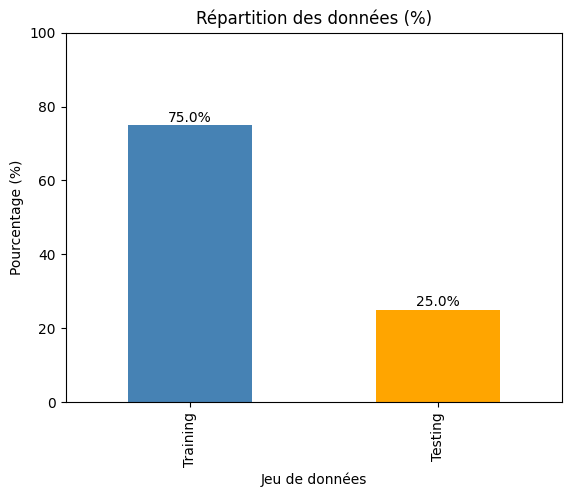

In [50]:
split_data.plot_data_split(train_data, test_data)

### d) Graphique de la répartition des données par LABEL

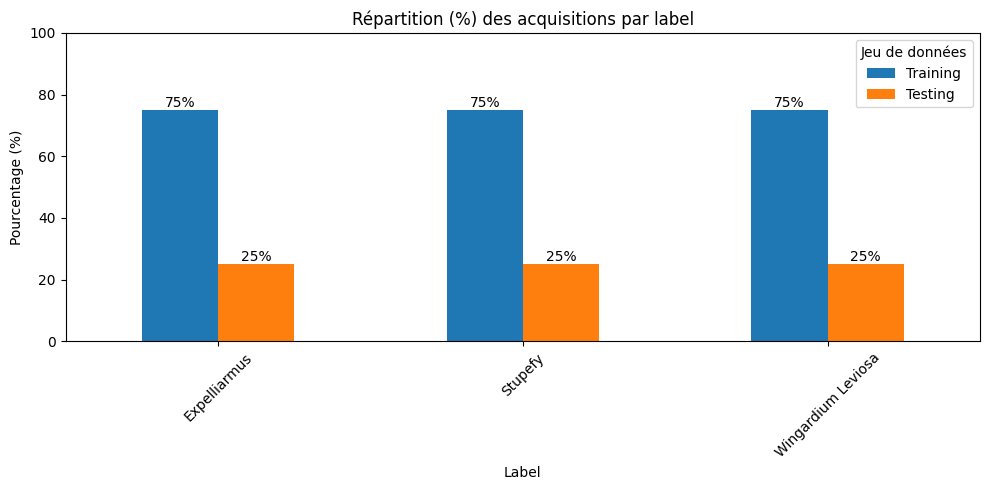

In [51]:
split_data.plot_label_split(train_data, test_data)

### e) Questions

**Retour au quizz moodle**

1) Faire le split avec un pourcentage de 25% de données de test, donnez ensuite le nombre de lignes des données de test
4) Pourquoi mélanger les données avant le split ?
5) Pourquoi est-il important d'avoir des données que le modèle n'a jamais vu?
6) Le jeu de test doit-il servir à entraîner le modèle?
8) Si l'on possède 300 acquisitions et que l'on a un split de 80/20, combien d'acquisitions sont utilisées pour l'entraînement ?
9) Associez ces concepts à leurs définitions: Training, validation, test

## 3. Analyse spectrale d'une donnée

Dans cette section, nous allons réaliser **l'analyse spectrale** d'une donnée en particulier. Nous allons d'abord observer son **image temporelle** pour ensuite l'analyser grâce à une **transformée de Fourier rapide (FFT)**. Cela nous permettra ensuite de générer des caractéristiques (**features**) pour toutes les données que l'on pourra utiliser pour entraîner et tester le modèle.


### a) Importation des fichiers/bibilothèques nécessaires

In [52]:
import analyse_spec

### b) Image temporelle de la donnée brute

In [53]:
#Choix d'une fonction à analyser

# Exemple d'utilisation de la fonction choisir_acquisition

sample = analyse_spec.choisir_acquisition(train_data, "Stupefy", 10)

#Votre code ici:



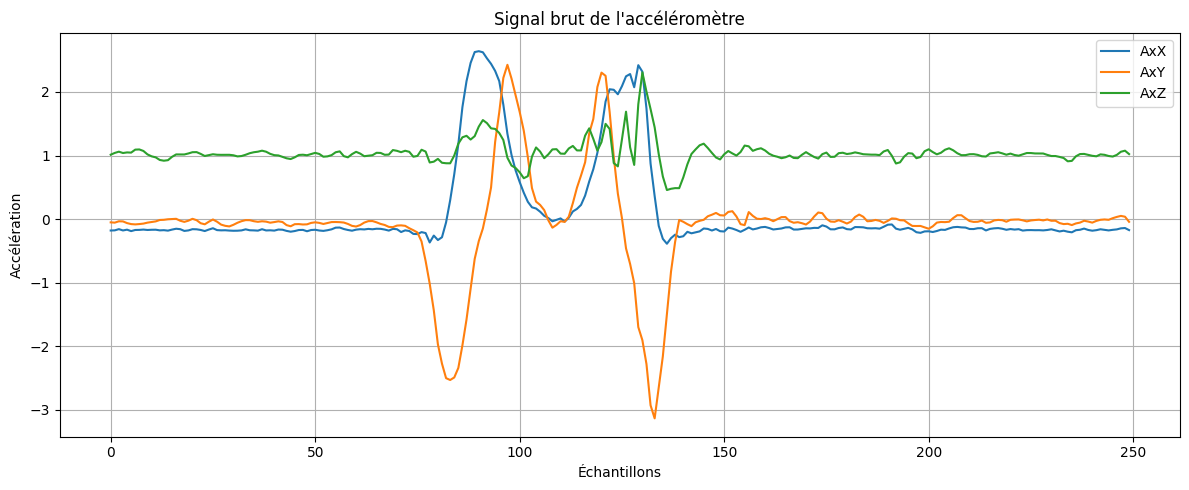

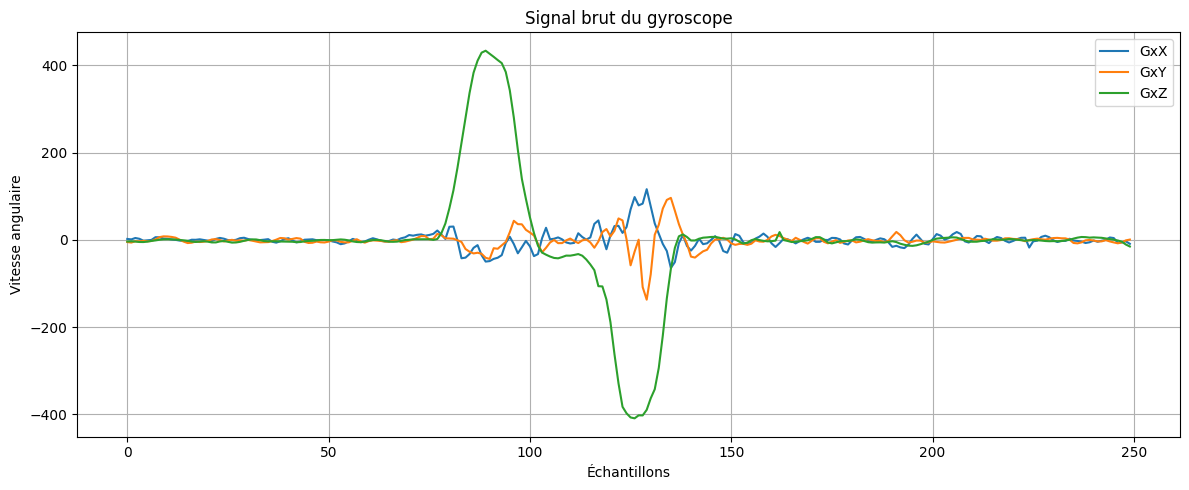

In [54]:
# Image en temporel de la donnée brute (accéléromètre)

analyse_spec.afficher_signaux_temporels(sample)

### c) Analyse spectrale de la donnée

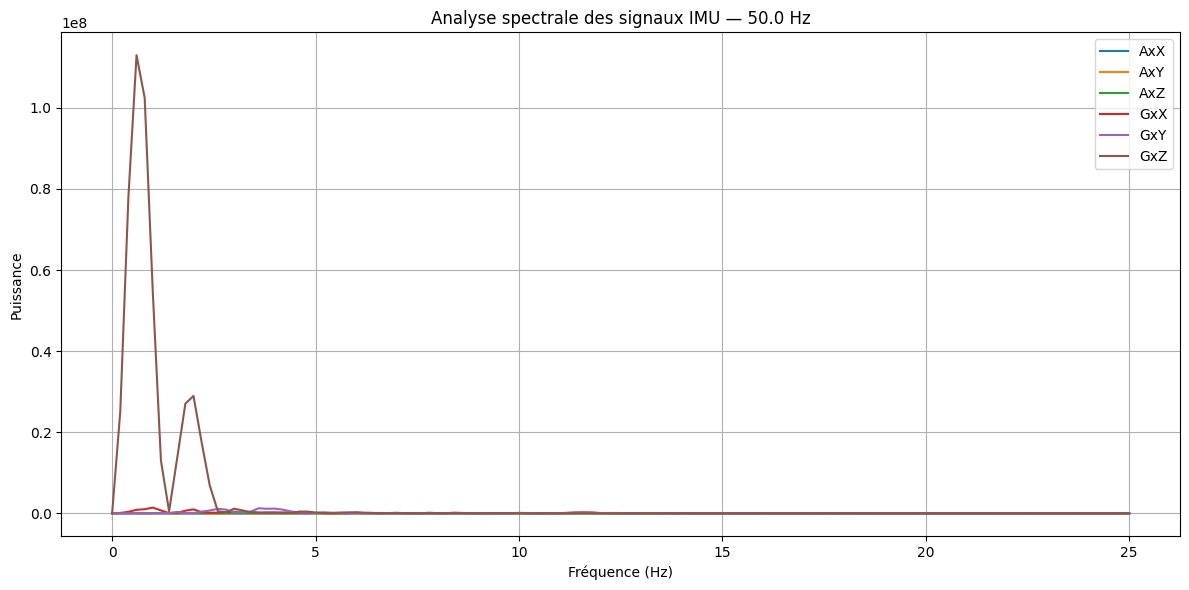

In [55]:
# Analyse spectrale (FFT)

resultats_fft = analyse_spec.afficher_analyse_spectrale(
    sample,
    interval_ms=20,
)

### d) Questions

**Retour au quizz moodle**

1) Pourquoi il est préférable de faire une analyse fréquentielle plutot qu'une analyse temporelle dans ce cas de figure? 
2) Quel type de filtre appliqueriez vous en observant l'analyse spectrale du signal Expelliarmus numéro 0? 
6) Sur le sort "Wingardium Leviosa" de numéro 2, quel est l'axe de l'IMU prédominant vers 2Hz?
7) Comment le bruit influence-t-il le spectre fréquentiel ?

## 4. Pré-traitement des données et génération de features

Ici, nous allons réaliser le **pré-traitement des données** avant l'entraînement du modèle:
* Nous allons d'abord réaliser un **split des données d'entraînement** en 2: celles qui vont servir à entraîner le modèle (**training set**) et celles qui vont servir à le valider et régler les hyperparamètres (**validation set**).
* Ensuite, nous allons réaliser l'analyse spectrale de toutes les données pour permettre la **génération de caractéristiques** (features) qui vont servir pour l'entraînement et le test.
* Nous allons également réaliser quelques traitements sur les features avant leur utilisation.

### a) Importation des fichiers/bibilothèques nécessaires

In [56]:
import pretraitement

### b) Split train/validation

In [57]:
#Fonction qui réalise le split train/validation

# Exempele deuxième découpage : Train / Validation à 60/40
# train_data, validation_data = pretraitement.split_train_validation(
#    train_data,
#    validation_size=0.4)

#Votre code ici:
train_data, validation_data = pretraitement.split_train_validation(
   train_data,
   validation_size=0.2)

Pourcentage de validation demandé : 20%
Nombre de lignes entraînement : 45113
Nombre de lignes validation : 11275

Répartition par label :


,Training,Validation,Total,% Validation
label,,,,
Expelliarmus,60,15,75,20.0
Stupefy,60,15,75,20.0
Wingardium Leviosa,60,15,75,20.0


### c) Génération des caractéristiques pour toutes les données

In [58]:
# Génération des features pour les trois jeux de données
features_train = pretraitement.construire_features(train_data)

#Votre code ici:
features_validation = pretraitement.construire_features(validation_data)
features_test = pretraitement.construire_features(test_data)

### d) Codage et normalisation des features

Ici, avant l'entraînement du modèle, il est important de **coder et normaliser** les caractéristiques pour permettre un entraînement optimal et efficace.

In [59]:
#Codage et normalisation des features

donnees_preparees = pretraitement.preparer_donnees_modele(
    features_train,
    features_validation,
    features_test,
)

X_train = donnees_preparees["X_train"]
X_validation = donnees_preparees["X_validation"]
X_test = donnees_preparees["X_test"]

y_train = donnees_preparees["y_train"]
y_validation = donnees_preparees["y_validation"]
y_test = donnees_preparees["y_test"]

X_train_scaled = donnees_preparees["X_train_scaled"]
X_validation_scaled = donnees_preparees["X_validation_scaled"]
X_test_scaled = donnees_preparees["X_test_scaled"]

y_train_encoded = donnees_preparees["y_train_encoded"]
y_validation_encoded = donnees_preparees["y_validation_encoded"]
y_test_encoded = donnees_preparees["y_test_encoded"]

label_encoder = donnees_preparees["label_encoder"]
scaler = donnees_preparees["scaler"]

Classes : ['Expelliarmus', 'Stupefy', 'Wingardium Leviosa']
Nombre de features : 138
Dimensions entraînement : (180, 138)
Dimensions validation : (45, 138)
Dimensions test : (75, 138)


### e) Questions

**Retour au quizz moodle**

1) Faire le split train/validation à 80/20, combien y-a-t-il de lignes pour les données de validation?
2) Quelle est la différence entre les données de test et les données de validation?
3) (CODE, pas de question moodle) Faire la génération des features pour les 2 jeux de données de validation et de tests en suivant l'exemple de celui de "features_train": utilisez les appelations "features_validation" et "features_test"
5) Pourquoi est-il important de pré-traiter les données avant l'entraînement?
6) Pourquoi est-il important de normaliser et coder les features avant l'entraînement?
9) Associez chacune de ses méthodes à leur definitions: Hold-Out, K-Fold et Leave-One-Out 

## 5. Classification sur données d'entraînement

Nous passons maintenant à la partie de l'**entraînement du modèle** avec **un réseau de neurones**, grâce aux données d'entraînement. 

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/reseau_neurones.png"
     alt="Réseau de neurones"
     width="600">

Cela nous permettra ensuite d'observer les **performances du modèle** (métriques, matrice de confusion) avec les données de validation qui serviront à régler le modèle et l'ajuster.

### a) Importation des fichiers nécessaires

In [60]:
import entrainement

### b) Création du réseau de neurones

In [61]:
#Architecture du réseau de neurones

num_features = X_train_scaled.shape[1]
num_classes = len(label_encoder.classes_)

model = entrainement.Sequential([
    entrainement.Dense(64, activation="relu", input_shape=(num_features,)),
    entrainement.Dropout(0.3),

    entrainement.Dense(32, activation="relu"),
    entrainement.Dropout(0.3),

    entrainement.Dense(num_classes, activation="softmax")
])

C:\Program Files\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### c) Compilation du modèle

In [62]:
# Compilation du modèle

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### d) Entraînement du modèle

In [63]:
#Entraînement 

early_stop = entrainement.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train_encoded,
    validation_data=(X_validation_scaled, y_validation_encoded),
    epochs=10,
    batch_size=16,
    callbacks=[early_stop]
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3944 - loss: 1.6144 - val_accuracy: 0.7556 - val_loss: 0.7374
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6056 - loss: 0.8798 - val_accuracy: 0.9778 - val_loss: 0.4092
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8056 - loss: 0.4872 - val_accuracy: 0.9778 - val_loss: 0.2500
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8333 - loss: 0.4477 - val_accuracy: 1.0000 - val_loss: 0.1675
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9000 - loss: 0.3235 - val_accuracy: 1.0000 - val_loss: 0.1145
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8944 - loss: 0.2666 - val_accuracy: 1.0000 - val_loss: 0.0847
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9278 - loss: 0.2317 - val_accuracy: 1.0000 - val_loss: 0.0668
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9333 - loss: 0.2116 - val_accuracy: 1.0000 - val_loss

### e) Performances de l'entraînement

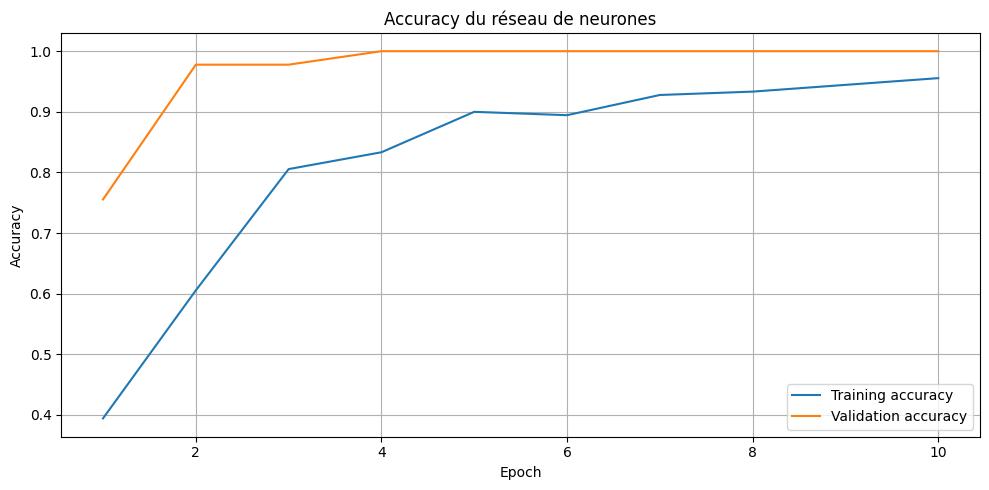

In [64]:
#Graphique de l'accuracy

entrainement.afficher_accuracy(history)

In [65]:
#Graphique de la fonction de perte du modèle

#Votre code ici:


In [66]:
# Prédictions sur le jeu de validation
y_validation_proba = model.predict(X_validation_scaled)
y_validation_pred = entrainement.np.argmax(y_validation_proba, axis=1)

#Métriques

metrics_validation = entrainement.afficher_metriques_classification(
    y_validation_encoded,
    y_validation_pred,
    y_validation_proba,
    titre="Métriques - Validation",
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Métriques - Validation


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


In [67]:
#Matrice de confusion

#Votre code ici:


### f) Questions

**Retour quizz moodle**

1) Combien de couches contient le réseau? Analysez l'architecture du réseau de neurone.
2) Quelle est la fonction d'activation utilisée pour la sortie du réseau de neurone?
3) Compilez et entraînez le modèle. Sur quoi le nombre d'époques a une/des conséquence(s)?
4) (CODE, pas de question moodle) Afficher la fonction de perte du réseau avec la fonction "entrainement.afficher_loss()", suivez l'exemple de la fonction permettant d'afficher l'accuracy.
5) Associez chaque métriques à sa définition
6) (CODE, pas de question moodle) Afficher la matrice de confusion avec "entrainement.afficher_matrice_confusion", si nécessaire aller voir sa définition dans le fichier dédié.
8) Comment obtenir la probabilité de détection et le ratio de faux positifs avec la matrice de confusion?
9) Quel est le rôle de la fonction d'activation ?
10) Comment détecter un surapprentissage à partir des courbes d'entraînement et de validation ?

## 6. Test du modèle

Pour cette dernière étape avant le déploiement embarqué sur carte du modèle, nous allons **tester le modèle** avec les données qu'il n'a jamais vu, les **données de test**. Ce test permettra d'avoir les **performances réelles du modèle** quand on lui présente de nouvelles données qui ne lui ont pas servi pour s'entraîner.

### a) Importation des fichiers/bibliothèques nécessaires

In [68]:
import entrainement

### b) Codage et normalisation des features

Ici, avant le test du modèle, il est important de **coder et normaliser** les caractéristiques pour permettre un test optimal et efficace.

In [69]:
# Données de test

X_test = features_test.drop(
    columns=["source_file", "label"]
)

y_test = features_test["label"]

# Encodage des labels
y_test_encoded = label_encoder.transform(y_test)

# Normalisation des caractéristiques
X_test_scaled = scaler.transform(X_test)

### c) Prédicition du modèle sur les données de test

In [70]:
# Prédictions sur le jeu de test
y_test_proba = model.predict(X_test_scaled)
y_test_pred = entrainement.np.argmax(y_test_proba, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


### d) Performance du modèle

In [71]:
metrics_test = entrainement.afficher_metriques_classification(
    y_test_encoded,
    y_test_pred,
    y_test_proba,
    titre="Métriques - Test",
)

Métriques - Test


Metric,Value
Area under ROC Curve,1.00
Weighted average Precision,1.00
Weighted average Recall,1.00
Weighted average F1 score,1.00


In [72]:
#Matrice de confusion

#Votre code ici:


### e) Questions

**Retour au quizz moodle**

1) (CODE, pas de question moodle) Afficher la matrice de confusion.
4) Pourquoi l'accuracy du test est-elle plus basse que celle de la validation lors de l'entraînement?
5) Que représentent les faux positifs? et les faux négatifs ?
6) Une accuracy de 100% garantit-il un modèle parfaitement fiable?

## **PARTIE 2: Déploiement du modèle sur la carte Seeed XIAO nRF52840 Sense**

Nous allons embarquer le réseau de neurones sur la carte Seeed Xiao NRF52840 Sense. Le notebook **exporte simplement les poids et les biais appris dans un fichier C++** (`model_params.h`). Sur la carte, une fonction C++ calcule directement les couches denses, les activations ReLU puis le softmax.

Le déroulement ensuite pour l'acquisition directe sur la carte est le suivant :

1. acquisition de mesures IMU à 50 Hz (fenêtre de 5 s) ;
2. calcul des mêmes caractéristiques que pendant l'entraînement ;
3. normalisation avec les paramètres du `StandardScaler` ;
4. inférence C++ : couche dense 138→32, ReLU, couche dense 32→16, ReLU, couche dense 16→classes, softmax ;
5. affichage de la classe et clignotement de la LED.

**Voici les étapes à suivre**: 
* Branchez la carte de la baguette magique à l'ordinateur via le cable USB
* IL EST IMPORTANT QUE L'ALIMENTATION DE LA BAGUETTE SOIT EN MODE OFF
* Réalisez ensuite les étapes qui suivent pour charger le modèle sur la carte et le tester sans le branchement à l'ordinateur

### a) Présentation de la carte Seeed Xiao NRF52840 sense

<img src="https://raw.githubusercontent.com/adarshbk12/Stage_IA/master/Seeed-Studio-XIAO-nRF52840-Sense.jpg" width="300">

La carte **Seeed Xiao NRF52840 sense** est équipée d'un **IMU** (Inertial Measurement Unit), qui renvoie les données d'un **gyroscope** (sur 3 axes) et d'un **accéléromètre** (sur 3 axes), cela nous permettra d'analyser les gestes réalisées.

Nous allons donc charger le modèle que nous avons entraîné sur cette carte, nous allons ensuite dans la PARTIE 3 enregistrer de nouvelles données grâce à celle-ci.

### b) Importation des fichiers/bibliothèques nécessaires

In [86]:
import deploiement

### c) Installation du support de la carte Seeed Xiao NRF52840 Sense

In [87]:
ARDUINO_CLI = deploiement.installer_support_xiao_nrf52840()

Arduino CLI détecté : .\arduino-cli.EXE
Vérification d'Arduino CLI...
arduino-cli  Version: 1.5.1 Commit: 01f3d4f2b Date: 2026-06-05T10:22:12Z

Vérification d'Arduino CLI réussie.
Mise à jour de l'index Seeed Studio...
Mise à jour de l'index Seeed Studio réussie.
Installation du support XIAO nRF52840...
Installation du support XIAO nRF52840 réussie.
Vérification des supports installés...
Vérification des supports installés réussie.

Support de la Seeed XIAO nRF52840 correctement installé.


### d) Installation des bibliothèques Arduino nécessaires

In [88]:
deploiement.installer_bibliotheque_lsm6ds3(
    ARDUINO_CLI
)

Installation de la bibliothèque « Seeed Arduino LSM6DS3 »...
Bibliothèque Seeed Arduino LSM6DS3 installée.


True

### e) Export des paramètres du modèle

In [89]:
deploiement.exporter_modele_cpp(
    model,
    scaler,
    label_encoder,
)

Fichier généré : \\netapp2\bassant-koum\Stage IA\Jupyter notebook\Sujet TP\Sujet final\model_params.h
Architecture : 138 -> 64 -> 32 -> 3
Labels : ['Expelliarmus', 'Stupefy', 'Wingardium Leviosa']
Paramètres exportés : 11075
Mémoire approximative des poids en float32 : 43.3 Kio


WindowsPath('//netapp2/bassant-koum/Stage IA/Jupyter notebook/Sujet TP/Sujet final/model_params.h')

### f) Déploiement du modèle sur carte

Ici, nous allons générer un **code Arduino contenant le modèle** qui sera implémenté sur la carte.

In [90]:
# ============================================================
# Génération, compilation et téléversement du sketch Arduino
# Inference directe en C++ : Dense + ReLU + Softmax
# ============================================================

informations_deploiement = deploiement.deployer_modele_xiao(
    arduino_code=deploiement.arduino_code,
    arduino_cli=ARDUINO_CLI,
    fichier_parametres="model_params.h",
)

Sketch généré : C:\temp\deploiement_xiao_cpp\deploiement_xiao_cpp.ino
Carte détectée : COM10 - Périphérique série USB (COM10)
Compilation en cours...
Compilation réussie.
Téléversement en cours...
Téléversement réussie.
Modèle correctement téléversé sur COM10
Ouverture du moniteur série...
Interrompez la cellule pour le fermer.

XIAO prete - inference C++ directe.
Correspondance labels / clignotements :
Expelliarmus : 1 clignotement
Stupefy : 2 clignotements
Wingardium Leviosa : 3 clignotements
Preparez le geste...
Sort reconnu : Expelliarmus | Score : 0.8551 | Clignotements attendus : 1

Moniteur série arrêté.


## **Testez maintenant le modèle en débranchant la carte et en allumant l'alimentation! (Faites des batailles de sort avec la baguette magique :))**

### g) Questions

**Retour au quizz moodle**

1) Pourquoi on parle de modèle « embarqué » ?
2) Quel contient le fichier `model_params.h`?
3) Le même pré-traitement doit-il être appliqué en Python et sur la carte?
8) Quelles contraintes de mémoire et de temps de calcul que l'on peut rencontrer?
9) Pourquoi la cadence réelle d'acquisition doit-elle rester proche de 50 Hz ?


## **PARTIE 3 : Ajouter un nouveau geste par fine-tuning**

Cette partie réalise toute la boucle d'amélioration du système :

1. remplacer temporairement le modèle embarqué par un firmware d'acquisition ;
2. enregistrer plusieurs exemples d'un nouveau label pendant 5 secondes à 50 Hz ;
3. adapter le modèle déjà entraîné en partie 1 sans repartir de poids aléatoires ;
4. exporter les nouveaux poids en C++ et ré-embarquer le modèle comme en partie 2.

Le fine-tuning consiste à reprendre un modèle déjà entraîné sur les anciens gestes et à l’entraîner encore un peu avec le nouveau geste.

Le modèle conserve ainsi ce qu’il a déjà appris, tout en adaptant ses paramètres pour reconnaître une classe supplémentaire. Pendant cette étape, il faut également lui présenter des exemples des anciens gestes afin qu’il ne les oublie pas.

Le fine-tuning réutilise le prétraitement, le `StandardScaler` et les couches cachées de la partie 1. La couche de sortie est agrandie afin d'ajouter le nouveau label. Les anciennes données sont mélangées aux nouvelles pour limiter l'oubli des sorts déjà connus.


## 1. Charger le firmware d'acquisition sur la carte

Le modèle de classification est temporairement remplacé par un programme simple. Lorsque Python envoie la commande `S`, la carte renvoie 250 mesures IMU, soit 5 secondes à 50 Hz, puis envoie `FIN`.

Les trois LED restent allumées pendant l'acquisition.


### a) Importation des fichiers/bibliothèques nécessaires

In [ ]:
import nouveau_label

### b) Téléversement du firmware d'acquisition 

In [ ]:
# Téléversement du firmware d'acquisition de nouvelles données

PORT = nouveau_label.charger_firmware_acquisition_xiao()

## 2. Enregistrer le nouveau label

Choisissez **Créer un nouveau label**, puis enregistrez idéalement au moins 20 acquisitions. Réalisez toujours le même geste, avec des variations naturelles de vitesse, d'orientation et d'amplitude.

### a) Importation des fichiers/bibliothèques nécessaires

In [ ]:
import nouvelle_acquisition
import deploiement

### b) Lancer le menu d'acquisition

In [ ]:
data = nouvelle_acquisition.menu_acquisition(
    dataset=data,
    fonction_trouver_port=nouvelle_acquisition.trouver_port_xiao,
)


### c) Questions sur l'acquisition

**Retour au quizz moodle**

1. Pourquoi faut-il conserver une fenêtre de 5 secondes et une fréquence de 50 Hz ?
2. Combien de gestes faut-il idéalement pour le nouveau label?
3. Pourquoi faut-il varier légèrement la vitesse et l'orientation sans changer la nature du geste ?

## 3. Fine-tuning du modèle de la partie 1

Cette étape ne recrée pas un réseau à partir de zéro :

- les deux couches cachées et leurs poids sont repris du modèle de la partie 1 ;
- la couche de sortie est agrandie ;
- les poids de sortie des anciens labels sont recopiés par nom ;
- le nouveau neurone de sortie est initialisé ;
- la tête est d'abord entraînée seule, puis tout le réseau est ajusté avec un faible taux d'apprentissage.

Le scaler de la partie 1 est conservé : le recalculer changerait la signification numérique des entrées et rendrait les anciens poids incohérents.


### a) Importation des fichiers/bibliothèques nécessaires

In [ ]:
import importlib
import nouveau_label
import pretraitement

importlib.reload(nouveau_label)

In [ ]:
model, scaler, label_encoder, resultats_finetuning = (
    nouveau_label.fine_tuner_avec_nouveau_label(
        model_base=model,
        scaler_base=scaler,
        label_encoder_base=label_encoder,
        dataset=data,
        fonction_construire_features=pretraitement.construire_features,
        epochs_tete=10,
        epochs_completes=20,
        batch_size=16,
        random_state=42,
    )
)

print(
    "Nouveau(x) label(s) :",
    resultats_finetuning["labels_ajoutes"],
)

print(
    "Classes embarquées :",
    list(label_encoder.classes_),
)

## 4. Ré-embarquer le modèle adapté

La cellule suivante régénère `model_params.h` avec la classe supplémentaire, puis reprend exactement la compilation, le téléversement et le moniteur série de la partie 2.

Après le téléversement, la légende du moniteur série doit contenir le nouveau label et son nombre de clignotements.


In [ ]:
import importlib
import nouveau_label
import deploiement

importlib.reload(nouveau_label)

In [ ]:
resultats_deploiement = (
    nouveau_label.exporter_et_deployer_modele_xiao(
        model=model,
        scaler=scaler,
        label_encoder=label_encoder,
        arduino_code=nouveau_label.arduino_code,

        fonction_exporter=deploiement.exporter_modele_cpp,
        fonction_deployer=deploiement.deployer_modele_xiao,

        arduino_cli=ARDUINO_CLI,
        fichier_parametres="model_params.h",
        ouvrir_moniteur=True,
    )
)

## Débranchez la carte et à vos baguettes sorciers !

# **FIN DU TP**

---

# **PARTIE 4 : Jeu — Bataille de sorts contre l’ordinateur**

Cette dernière partie transforme la reconnaissance embarquée sur la carte en un petit jeu de type **pierre-papier-ciseaux**.

La carte doit rester **branchée en USB à l’ordinateur** et le firmware de reconnaissance doit être déjà embarqué. Python ne refait pas l’inférence : il écoute le **port série** et attend que la carte annonce l’un des trois sorts reconnus.

Règles retenues pour former un cycle :

- **Stupefy** bat **Wingardium Leviosa** ;
- **Wingardium Leviosa** bat **Expelliarmus** ;
- **Expelliarmus** bat **Stupefy** ;
- deux sorts identiques donnent une égalité.

À chaque manche :

1. cliquer sur **Jouer à la bataille de sorts** ;
2. réaliser un geste avec la baguette ;
3. Python récupère le sort reconnu par la carte ;
4. l’ordinateur choisit aléatoirement son sort ;
5. le gagnant marque un point ;
6. les choix **Rejouer**, **Voir les scores** et **Quitter la partie** sont proposés.

> **Important :** fermer auparavant tout moniteur série Arduino/Python qui utiliserait déjà la carte, car un port série ne peut généralement être ouvert que par un programme à la fois.


### Synchronisation avec le firmware réel

Le firmware fourni dans `deploiement.py` et `nouveau_label.py` communique à **115200 bauds** et envoie les prédictions sous la forme :

`Sort reconnu : <LABEL> | Score : <probabilité> | Clignotements attendus : <n>`

Le jeu attend aussi le message `Preparez le geste...` avant chaque acquisition. Ainsi, une manche ne récupère pas par erreur une prédiction qui aurait commencé avant le clic sur **Jouer**. Les lignes de démarrage qui listent les labels sont ignorées.


In [93]:
import random
import re
import threading
import time
import tkinter as tk
from tkinter import messagebox, ttk

import serial
from serial.tools import list_ports


SORTS = ("Stupefy", "Wingardium Leviosa", "Expelliarmus")

# Cycle de victoire, comme pierre-papier-ciseaux :
# clé = sort joué ; valeur = sort qu'il bat.
BAT = {
    "Stupefy": "Wingardium Leviosa",
    "Wingardium Leviosa": "Expelliarmus",
    "Expelliarmus": "Stupefy",
}


def trouver_ports_possibles():
    """Retourne les ports série détectés, avec priorité aux ports qui ressemblent à une XIAO."""
    ports = list(list_ports.comports())

    def priorite(p):
        texte = f"{p.device} {p.description} {p.manufacturer or ''}".lower()
        mots_cles = ("xiao", "seeed", "nrf52840", "arduino", "usb serial", "cdc")
        return 0 if any(mot in texte for mot in mots_cles) else 1

    return sorted(ports, key=priorite)


def extraire_sort(ligne):
    """Extrait uniquement une vraie prédiction du firmware d'inférence."""
    if not ligne or not ligne.startswith("Sort reconnu :"):
        return None

    # Format réel de deploiement.py / nouveau_label.py :
    # Sort reconnu : <LABEL> | Score : <proba> | Clignotements attendus : <n>
    contenu = ligne.split("Sort reconnu :", 1)[1]
    label = contenu.split("|", 1)[0].strip()

    correspondances = {
        "stupefy": "Stupefy",
        "wingardium leviosa": "Wingardium Leviosa",
        "wingardium_leviosa": "Wingardium Leviosa",
        "expelliarmus": "Expelliarmus",
    }
    return correspondances.get(label.lower())



class BatailleDeSorts:
    def __init__(self, root, baudrate=115200):
        self.root = root
        self.baudrate = baudrate
        self.serial = None
        self.thread_lecture = None
        self.stop_lecture = threading.Event()

        # Synchronisation avec le firmware
        self.attend_sort = False
        self.attend_prepare = False

        # Identifiant du timeout de la manche
        self.timeout_manche_id = None

        # Scores généraux
        self.score_joueur = 0
        self.score_ordinateur = 0
        self.egalites = 0
        self.manches = 0

        # Mode de jeu
        self.mode_jeu = "simple"
        self.duel_actif = False
        self.numero_sort_duel = 0
        self.score_duel_joueur = 0
        self.score_duel_ordinateur = 0
        self.egalites_duel = 0

        # Animation
        self.animation_en_cours = False
        self.animation_ids = []

        self.root.title("Bataille de sorts")
        self.root.geometry("850x680")
        self.root.minsize(760, 620)
        self.root.protocol("WM_DELETE_WINDOW", self.quitter)

        self.port_var = tk.StringVar()
        self.etat_var = tk.StringVar(value="Carte non connectée")
        self.message_var = tk.StringVar(
            value="Connectez la carte puis choisissez un mode de jeu."
        )
        self.score_var = tk.StringVar()
        self.duel_var = tk.StringVar(value="Aucun duel en 5 sorts en cours.")

        self._construire_interface()
        self._mettre_score_a_jour()
        self.actualiser_ports()

    def _construire_interface(self):
        cadre = ttk.Frame(self.root, padding=20)
        cadre.pack(fill="both", expand=True)

        ttk.Label(
            cadre,
            text="⚡ Bataille de sorts ⚡",
            font=("Arial", 24, "bold")
        ).pack(pady=(0, 8))

        ttk.Label(
            cadre,
            text="Stupefy > Wingardium Leviosa > Expelliarmus > Stupefy",
            font=("Arial", 11),
        ).pack(pady=(0, 14))

        connexion = ttk.LabelFrame(
            cadre,
            text="Connexion à la baguette",
            padding=12
        )
        connexion.pack(fill="x", pady=(0, 12))

        ligne_port = ttk.Frame(connexion)
        ligne_port.pack(fill="x")

        ttk.Label(ligne_port, text="Port série :").pack(side="left")

        self.combo_ports = ttk.Combobox(
            ligne_port,
            textvariable=self.port_var,
            state="readonly",
            width=42
        )
        self.combo_ports.pack(
            side="left",
            padx=8,
            fill="x",
            expand=True
        )

        ttk.Button(
            ligne_port,
            text="Actualiser",
            command=self.actualiser_ports
        ).pack(side="left", padx=4)

        self.btn_connexion = ttk.Button(
            ligne_port,
            text="Connecter",
            command=self.basculer_connexion
        )
        self.btn_connexion.pack(side="left", padx=4)

        ttk.Label(
            connexion,
            textvariable=self.etat_var
        ).pack(anchor="w", pady=(8, 0))

        zone_jeu = ttk.LabelFrame(
            cadre,
            text="Duel",
            padding=14
        )
        zone_jeu.pack(fill="both", expand=True)

        ttk.Label(
            zone_jeu,
            textvariable=self.message_var,
            font=("Arial", 14, "bold"),
            wraplength=720,
            justify="center",
        ).pack(pady=(8, 4))

        ttk.Label(
            zone_jeu,
            textvariable=self.score_var,
            font=("Arial", 12)
        ).pack(pady=4)

        ttk.Label(
            zone_jeu,
            textvariable=self.duel_var,
            font=("Arial", 11, "italic")
        ).pack(pady=(2, 8))

        # Canvas pour les effets magiques.
        self.canvas = tk.Canvas(
            zone_jeu,
            height=180,
            bg="#101020",
            highlightthickness=0
        )
        self.canvas.pack(fill="x", pady=(4, 10))

        # Décoration magique au centre du Canvas
        self.decor_id = self.canvas.create_text(
            0,
            0,
            text="✦  ✧  ✦",
            fill="white",
            font=("Arial", 28, "bold"),
            tags="decor"
        )

        # Cette fonction est appelée automatiquement
        # lorsque le Canvas change de taille.
        def redimensionner_canvas(event):
            self.canvas.coords(
                self.decor_id,
                event.width / 2,
                event.height / 2
            )

        # Détecte automatiquement les redimensionnements
        self.canvas.bind("<Configure>", redimensionner_canvas)

        boutons_modes = ttk.Frame(cadre)
        boutons_modes.pack(fill="x", pady=(12, 4))

        self.btn_jouer = ttk.Button(
            boutons_modes,
            text="1. Jouer une manche",
            command=self.jouer
        )
        self.btn_jouer.pack(
            side="left",
            padx=4,
            expand=True,
            fill="x"
        )

        self.btn_duel5 = ttk.Button(
            boutons_modes,
            text="2. Duel en 5 sorts",
            command=self.lancer_duel_5_sorts
        )
        self.btn_duel5.pack(
            side="left",
            padx=4,
            expand=True,
            fill="x"
        )

        boutons_utilitaires = ttk.Frame(cadre)
        boutons_utilitaires.pack(fill="x", pady=(4, 0))

        ttk.Button(
            boutons_utilitaires,
            text="3. Voir les scores",
            command=self.voir_scores
        ).pack(side="left", padx=4, expand=True, fill="x")

        ttk.Button(
            boutons_utilitaires,
            text="4. Réinitialiser les scores",
            command=self.reinitialiser_scores
        ).pack(side="left", padx=4, expand=True, fill="x")

        ttk.Button(
            boutons_utilitaires,
            text="5. Quitter",
            command=self.quitter
        ).pack(side="left", padx=4, expand=True, fill="x")

    def actualiser_ports(self):
        ports = trouver_ports_possibles()
        valeurs = [
            f"{p.device} — {p.description}"
            for p in ports
        ]

        self.combo_ports["values"] = valeurs

        if valeurs:
            self.combo_ports.current(0)
            self.etat_var.set(
                "Port détecté. Cliquez sur Connecter."
            )
        else:
            self.port_var.set("")
            self.etat_var.set(
                "Aucun port série détecté. "
                "Branchez la carte puis cliquez sur Actualiser."
            )

    def _device_selectionne(self):
        selection = self.port_var.get().strip()
        if not selection:
            return None
        return selection.split(" — ", 1)[0]

    def basculer_connexion(self):
        if self.serial and self.serial.is_open:
            self.deconnecter()
        else:
            self.connecter()

    def connecter(self):
        port = self._device_selectionne()

        if not port:
            messagebox.showwarning(
                "Connexion",
                "Aucun port série n'est sélectionné."
            )
            return

        try:
            connexion = serial.Serial(
                port,
                self.baudrate,
                timeout=0.2
            )

            time.sleep(1.5)
            connexion.reset_input_buffer()

            self.serial = connexion

            # IMPORTANT :
            # un nouvel Event pour un nouveau thread.
            stop_event = threading.Event()
            self.stop_lecture = stop_event

            self.thread_lecture = threading.Thread(
                target=self._boucle_lecture,
                args=(stop_event,),
                daemon=True
            )

            self.thread_lecture.start()

            self.etat_var.set(
                f"Connectée à {port} à {self.baudrate} bauds."
            )

            self.btn_connexion.config(
                text="Déconnecter"
            )

            self.message_var.set(
                "Carte prête. Choisissez une manche simple "
                "ou un duel en 5 sorts."
            )

        except Exception as exc:
            self.serial = None

            messagebox.showerror(
                "Connexion impossible",
                f"Impossible d'ouvrir {port}.\n\n"
                f"{exc}\n\n"
                "Vérifiez qu'aucun moniteur série "
                "n'utilise déjà la carte."
            )

    def deconnecter(self):
        self.attend_sort = False
        self.attend_prepare = False
        self.duel_actif = False

        self._annuler_timeout_manche()

        if self.stop_lecture:
            self.stop_lecture.set()

        connexion = self.serial
        self.serial = None

        try:
            if connexion and connexion.is_open:
                connexion.close()
        except Exception:
            pass

        self.thread_lecture = None

        self.btn_connexion.config(text="Connecter")
        self.etat_var.set("Carte déconnectée.")
        self._activer_boutons_jeu()

    def _carte_connectee(self):
        if not (
            self.serial
            and self.serial.is_open
        ):
            messagebox.showwarning(
                "Carte non connectée",
                "Connectez d'abord la XIAO au port série."
            )
            return False
        return True

    def jouer(self):
        """Lance une manche simple."""
        if not self._carte_connectee():
            return

        if self.duel_actif:
            messagebox.showinfo(
                "Duel en cours",
                "Terminez d'abord le duel en 5 sorts."
            )
            return

        self.mode_jeu = "simple"
        self._armer_prochaine_manche(
            "Manche simple armée. Attendez le signal de la carte…"
        )

    def lancer_duel_5_sorts(self):
        """Lance une partie composée exactement de cinq sorts."""
        if not self._carte_connectee():
            return

        if self.attend_prepare or self.attend_sort:
            return

        self.mode_jeu = "duel5"
        self.duel_actif = True
        self.numero_sort_duel = 0
        self.score_duel_joueur = 0
        self.score_duel_ordinateur = 0
        self.egalites_duel = 0

        self._mettre_duel_a_jour()
        self._armer_prochaine_manche(
            "⚔ Duel en 5 sorts lancé !\n"
            "Sort 1/5 : attendez le signal de la carte…"
        )

    def _annuler_timeout_manche(self):
        if self.timeout_manche_id is not None:
            try:
                self.root.after_cancel(
                    self.timeout_manche_id
                )
            except Exception:
                pass

            self.timeout_manche_id = None

    def _armer_prochaine_manche(self, message):
        self.attend_sort = False
        self.attend_prepare = True

        self.btn_jouer.config(state="disabled")
        self.btn_duel5.config(state="disabled")
        self.message_var.set(message)

        # Annuler un ancien timeout
        self._annuler_timeout_manche()

        # On laisse jusqu'à 15 secondes pour attendre
        # le prochain "Preparez le geste..."
        self.timeout_manche_id = self.root.after(
            15000,
            self._timeout_manche
        )

    def _timeout_manche(self):
        self.timeout_manche_id = None

        if not (
            self.attend_prepare
            or self.attend_sort
        ):
            return

        self.attend_prepare = False
        self.attend_sort = False

        self.message_var.set(
            "⚠ Aucun signal reçu de la carte.\n\n"
            "La manche a été annulée. "
            "Vous pouvez réessayer."
        )

        self.duel_actif = False
        self._activer_boutons_jeu()

    def _demarrer_timeout_prediction(self):
        # Le signal "Preparez le geste" a été reçu.
        # Le premier timeout n'est donc plus utile.
        self._annuler_timeout_manche()

        # La XIAO acquiert environ 5 secondes de données.
        # On laisse 10 secondes pour recevoir la prédiction.
        self.timeout_manche_id = self.root.after(
            10000,
            self._timeout_manche
        )

    def _boucle_lecture(self, stop_event):
        while not stop_event.is_set():
            try:
                if not self.serial or not self.serial.is_open:
                    break

                brut = self.serial.readline()

                if not brut:
                    continue

                ligne = brut.decode(
                    "utf-8",
                    errors="ignore"
                ).strip()

                if (
                    self.attend_prepare
                    and ligne.startswith("Preparez le geste")
                ):
                    self.attend_prepare = False
                    self.attend_sort = True
                    self.root.after(
                        0,
                        self._demarrer_timeout_prediction
                    )

                    if self.mode_jeu == "duel5":
                        texte = (
                            f"⚡ Sort {self.numero_sort_duel + 1}/5 ⚡\n"
                            "À vous ! Réalisez votre sort maintenant…"
                        )
                    else:
                        texte = (
                            "⚡ À vous ! La carte lance l'acquisition : "
                            "réalisez votre sort maintenant…"
                        )

                    self.root.after(
                        0,
                        self.message_var.set,
                        texte
                    )
                    continue

                sort_reconnu = extraire_sort(ligne)

                if self.attend_sort and sort_reconnu:
                    self.attend_sort = False
                    self.root.after(
                        0,
                        self._terminer_manche,
                        sort_reconnu
                    )

            except Exception as exc:
                if not stop_event.is_set():
                    self.root.after(
                        0,
                        self._erreur_serie,
                        str(exc)
                    )
                break

    def _erreur_serie(self, message):
        self.deconnecter()
        messagebox.showerror(
            "Erreur série",
            message
        )

    def _calculer_resultat(self, sort_joueur, sort_ordinateur):
        if sort_joueur == sort_ordinateur:
            return "egalite"

        if BAT[sort_joueur] == sort_ordinateur:
            return "joueur"

        return "ordinateur"

    def _terminer_manche(self, sort_joueur):

        # Le sort a bien été reçu :
        # on annule le timeout de la manche.
        self._annuler_timeout_manche()

        # L'ordinateur choisit son sort
        sort_ordinateur = random.choice(SORTS)

        gagnant = self._calculer_resultat(
            sort_joueur,
            sort_ordinateur
        )

        self.manches += 1

        if gagnant == "egalite":
            self.egalites += 1
            resultat = "Égalité : aucun point marqué."

            if self.duel_actif:
                self.egalites_duel += 1

        elif gagnant == "joueur":
            self.score_joueur += 1
            resultat = "✨ Vous gagnez cette manche : +1 point !"

            if self.duel_actif:
                self.score_duel_joueur += 1

        else:
            self.score_ordinateur += 1
            resultat = "💥 L'ordinateur gagne cette manche."

            if self.duel_actif:
                self.score_duel_ordinateur += 1

        self._mettre_score_a_jour()

        if self.duel_actif:
            self.numero_sort_duel += 1
            self._mettre_duel_a_jour()

            self.message_var.set(
                f"Votre sort : {sort_joueur}\n"
                f"Sort de l'ordinateur : {sort_ordinateur}\n\n"
                f"{resultat}\n\n"
                f"Score du duel : "
                f"{self.score_duel_joueur} - "
                f"{self.score_duel_ordinateur}"
            )

            if self.numero_sort_duel >= 5:
                self.duel_actif = False
                self.root.after(
                    900,
                    self._terminer_duel_5_sorts
                )
            else:
                self.root.after(
                    1200,
                    self._continuer_duel_5_sorts
                )

        else:
            self.message_var.set(
                f"Votre sort : {sort_joueur}\n"
                f"Sort de l'ordinateur : {sort_ordinateur}\n\n"
                f"{resultat}\n\n"
                "Choisissez : rejouer, lancer un duel en 5 sorts, "
                "voir les scores ou quitter."
            )
            self._activer_boutons_jeu()

    def _continuer_duel_5_sorts(self):
        if not self.serial or not self.serial.is_open:
            return

        self._armer_prochaine_manche(
            f"⚔ Duel en cours — sort "
            f"{self.numero_sort_duel + 1}/5\n"
            "Attendez le prochain signal de la carte…"
        )

    def _terminer_duel_5_sorts(self):
        self._mettre_duel_a_jour()

        if (
            self.score_duel_joueur
            > self.score_duel_ordinateur
        ):
            texte = (
                "🏆 VICTOIRE ! 🏆\n\n"
                f"Vous remportez le duel "
                f"{self.score_duel_joueur} à "
                f"{self.score_duel_ordinateur}."
            )
            self._animation_magique(
                victoire=True,
                texte="VICTOIRE !"
            )

        elif (
            self.score_duel_joueur
            < self.score_duel_ordinateur
        ):
            texte = (
                "☠ DÉFAITE ☠\n\n"
                f"L'ordinateur remporte le duel "
                f"{self.score_duel_ordinateur} à "
                f"{self.score_duel_joueur}."
            )
            self._animation_magique(
                victoire=False,
                texte="DÉFAITE"
            )

        else:
            texte = (
                "⚡ ÉGALITÉ MAGIQUE ⚡\n\n"
                f"Le duel se termine sur "
                f"{self.score_duel_joueur} à "
                f"{self.score_duel_ordinateur}."
            )
            self._animation_magique(
                victoire=None,
                texte="ÉGALITÉ"
            )

        if self.egalites_duel:
            texte += (
                f"\nÉgalités pendant le duel : "
                f"{self.egalites_duel}"
            )

        self.message_var.set(
            texte
            + "\n\nVous pouvez lancer une nouvelle partie."
        )

        self._activer_boutons_jeu()

    def _mettre_score_a_jour(self):
        self.score_var.set(
            f"Score général — Vous : {self.score_joueur}"
            f"   |   Ordinateur : {self.score_ordinateur}"
            f"   |   Égalités : {self.egalites}"
        )

    def _mettre_duel_a_jour(self):
        if self.mode_jeu == "duel5" and (
            self.duel_actif
            or self.numero_sort_duel > 0
        ):
            self.duel_var.set(
                f"Duel 5 sorts — "
                f"{self.numero_sort_duel}/5 joués"
                f"   |   Vous : {self.score_duel_joueur}"
                f"   |   Ordinateur : {self.score_duel_ordinateur}"
                f"   |   Égalités : {self.egalites_duel}"
            )
        else:
            self.duel_var.set(
                "Aucun duel en 5 sorts en cours."
            )

    def voir_scores(self):
        if self.score_joueur > self.score_ordinateur:
            situation = "Vous êtes en tête !"
        elif self.score_joueur < self.score_ordinateur:
            situation = "L'ordinateur est en tête."
        else:
            situation = "Les scores sont à égalité."

        message = (
            f"Manches jouées : {self.manches}\n\n"
            f"Vous : {self.score_joueur}\n"
            f"Ordinateur : {self.score_ordinateur}\n"
            f"Égalités : {self.egalites}\n\n"
            f"{situation}"
        )

        if self.numero_sort_duel > 0:
            message += (
                "\n\nDernier / actuel duel en 5 sorts :\n"
                f"Vous : {self.score_duel_joueur}\n"
                f"Ordinateur : {self.score_duel_ordinateur}\n"
                f"Égalités : {self.egalites_duel}"
            )

        messagebox.showinfo(
            "Scores",
            message
        )

    def reinitialiser_scores(self):
        if self.attend_prepare or self.attend_sort:
            messagebox.showwarning(
                "Manche en cours",
                "Attendez la fin de la manche avant "
                "de réinitialiser les scores."
            )
            return

        confirmer = messagebox.askyesno(
            "Réinitialiser les scores",
            "Voulez-vous remettre tous les scores à zéro ?"
        )

        if not confirmer:
            return

        self.score_joueur = 0
        self.score_ordinateur = 0
        self.egalites = 0
        self.manches = 0

        self.duel_actif = False
        self.numero_sort_duel = 0
        self.score_duel_joueur = 0
        self.score_duel_ordinateur = 0
        self.egalites_duel = 0
        self.mode_jeu = "simple"

        self._mettre_score_a_jour()
        self._mettre_duel_a_jour()
        self._effacer_animation()

        self.message_var.set(
            "✨ Scores réinitialisés. "
            "Choisissez un nouveau mode de jeu."
        )

    def _activer_boutons_jeu(self):
        self.btn_jouer.config(
            state="normal",
            text="1. Jouer une manche"
        )
        self.btn_duel5.config(state="normal")

    def _effacer_animation(self):
        for animation_id in self.animation_ids:
            try:
                self.root.after_cancel(animation_id)
            except Exception:
                pass

        self.animation_ids.clear()
        self.animation_en_cours = False
        self.canvas.delete("magic")

    def _animation_magique(self, victoire=True, texte="VICTOIRE !"):
        """Petite animation Tkinter sans dépendance externe."""
        self._effacer_animation()
        self.animation_en_cours = True

        self.canvas.update_idletasks()

        largeur = self.canvas.winfo_width()
        hauteur = self.canvas.winfo_height()

        # Fond étoilé
        for _ in range(55):
            x = random.randint(0, largeur)
            y = random.randint(0, hauteur)
            r = random.choice((1, 1, 2, 2, 3))

            self.canvas.create_oval(
                x - r,
                y - r,
                x + r,
                y + r,
                fill=random.choice(
                    ("white", "#ffe680", "#c8d7ff")
                ),
                outline="",
                tags="magic"
            )

        if victoire is True:
            couleur_texte = "#ffe66d"
            symbole = "⚡ ✨ ⚡"
        elif victoire is False:
            couleur_texte = "#ff7070"
            symbole = "☠ ⚡ ☠"
        else:
            couleur_texte = "#d8b4ff"
            symbole = "⚡ ✦ ⚡"

        self.canvas.create_text(
            largeur // 2,
            hauteur // 2 - 16,
            text=symbole,
            fill=couleur_texte,
            font=("Arial", 26, "bold"),
            tags="magic"
        )

        self.canvas.create_text(
            largeur // 2,
            hauteur // 2 + 30,
            text=texte,
            fill=couleur_texte,
            font=("Arial", 24, "bold"),
            tags="magic"
        )

        def dessiner_eclair():
            if not self.animation_en_cours:
                return

            self.canvas.delete("lightning")

            for _ in range(4):
                x = random.randint(
                    40,
                    max(41, largeur - 40)
                )

                points = [
                    x,
                    0
                ]

                y = 0
                while y < hauteur:
                    y += random.randint(18, 30)
                    x += random.randint(-28, 28)
                    points.extend([x, y])

                self.canvas.create_line(
                    *points,
                    fill=random.choice(
                        ("white", "#fff176", "#b9d6ff", "#d7b5ff")
                    ),
                    width=random.choice((2, 3, 4)),
                    tags=("magic", "lightning")
                )

            animation_id = self.root.after(
                170,
                dessiner_eclair
            )
            self.animation_ids.append(animation_id)

        dessiner_eclair()

        # L'animation s'arrête automatiquement.
        def arreter():
            self.animation_en_cours = False
            self.canvas.delete("lightning")

        animation_id = self.root.after(
            3200,
            arreter
        )
        self.animation_ids.append(animation_id)

    def quitter(self):
        self._effacer_animation()
        self.deconnecter()
        self.root.destroy()


def lancer_bataille_de_sorts(baudrate=115200):
    """Ouvre l'interface graphique du jeu."""
    root = tk.Tk()
    app = BatailleDeSorts(
        root,
        baudrate=baudrate
    )
    root.mainloop()
    return app



### Lancer le jeu

La cellule suivante ouvre la fenêtre Python. La carte doit rester branchée en USB.


In [96]:
lancer_bataille_de_sorts()
